# City-scale climate metrics in an ensemble of CPRCM-emulator output

_Jesus Fernandez / Instituto de Física de Cantabria (IFCA), CSIC-Universidad de Cantabria_

This notebook is an illustrative walkthrough of daily CPRCM emulator output for a user-selected city and diagnostic metric. It inspects how individual emulator members behave, how they compare with each other, and how I4C WP5 blending methods ranking the members can be used to subset the member for a given period.

The active example uses daily maximum temperature (`tasmax`) and summarizes each year as the maximum 15-day running mean. That diagnostic is only one choice: the same workflow can also be pointed at other variables and yearly summaries, such as winter mean precipitation, by changing the metric configuration near the top of the notebook.

The workflow is organized around a reusable pattern: load emulator output, define a yearly diagnostic, build a cached member-level dataset, convert the series into anomalies relative to a historical reference period, and compare the emulator members against an observational reference and a subset of members ranked by different methodologies.

The diagnostic itself is isolated in standalone functions so you can change the climate metric without rewriting the file discovery, caching, ranking, or plotting workflow.

## 1. Configuration

This section defines the selected city, local paths, active climate metric, diagnostic settings, and a few user-facing controls such as whether some members should be highlighted. In normal use, this is the main cell to edit before re-running the notebook.

The active settings keep the current `tasmax` example. A commented precipitation alternative is included to show the small set of values that would need to change e.g. for a winter mean precipitation analysis.

In [1]:
config = dict(
    CITY="Barcelona",
    VARIABLE="tasmax",  # "pr", "tasmin"
    DIAGNOSTIC_ID="annual_max_15day_mean",  # "winter_mean", "tn20"
    REFERENCE_PERIOD=slice(1995, 2014),
    HIGHLIGHT_MEMBERS=["NorESM2-MM_historical_r1i1p1f1", "NorESM2-MM_ssp370_r1i1p1f1"],
    RANKING_METHOD="Blend2C",
    RANKING_START_YEAR=1981,
    FORCE_RECOMPUTE=False,
)


Library imports and other more technical configuration variables:

In [2]:
import re
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
# Notebook aliases keep the analysis cells readable; functions below receive config explicitly.
globals().update(config)

CITY_PREFIX = f"NSEA-3i-{CITY}" if CITY == "Bergen" else f"ALPX-3i-{CITY}"
DATA_DIR = Path("../I4C_EMULATOR_CITY_DATA") / CITY_PREFIX
CPRCM_DATA_DIR = Path("../I4C_CPRCM_CITY_DATA") / CITY_PREFIX
CACHE_BASE_DIR = Path("../CACHE")
CACHE_PATH = CACHE_BASE_DIR / f"{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}.nc"
EOBS_VARIABLE = dict(pr="rr", tasmax="tx", tasmin="tn")[config["VARIABLE"]]
EOBS_URL = f"https://knmi-ecad-assets-prd.s3.amazonaws.com/ensembles/data/Grid_0.1deg_reg_ensemble/{EOBS_VARIABLE}_ens_mean_0.1deg_reg_v33.0e.nc"
EOBS_CACHE_PATH = CACHE_BASE_DIR / f"{EOBS_VARIABLE}_ens_mean_0.1deg_reg_v33.0e.nc"
EOBS_METRIC_CACHE_PATH = CACHE_BASE_DIR / f"{CITY}_EOBS_{VARIABLE}_{DIAGNOSTIC_ID}.nc"
CPRCM_CACHE_PATH = CACHE_BASE_DIR / f"{CITY}_CPRCM_{VARIABLE}_{DIAGNOSTIC_ID}.nc"
FIGURE_DIR = Path("FIGURES") / CITY_PREFIX

city_locations = {
    "Barcelona": (41.3874, 2.1686),
    "Paris": (48.8566, 2.3522),
    "Bergen": (60.39299, 5.32415),
    "Prague": (50.0755, 14.4378),
}
if CITY not in city_locations:
    raise ValueError(f"Unknown city: {CITY}")
TARGET_LAT, TARGET_LON = city_locations[CITY]

config.update(
    CITY_PREFIX = CITY_PREFIX,
    DATA_DIR = DATA_DIR,
    CPRCM_DATA_DIR=CPRCM_DATA_DIR,
    CACHE_BASE_DIR=CACHE_BASE_DIR,
    CACHE_PATH=CACHE_PATH,
    EOBS_VARIABLE=EOBS_VARIABLE,
    EOBS_URL=EOBS_URL,
    EOBS_CACHE_PATH=EOBS_CACHE_PATH,
    EOBS_METRIC_CACHE_PATH=EOBS_METRIC_CACHE_PATH,
    CPRCM_CACHE_PATH=CPRCM_CACHE_PATH,
    FIGURE_DIR=FIGURE_DIR,
    TARGET_LAT=TARGET_LAT,
    TARGET_LON=TARGET_LON,
    OPEN_CHUNKS=None,
)
globals().update(config)

print(f"City: {CITY}")
print(f"Data directory: {DATA_DIR}")
print(f"CPRCM data directory: {CPRCM_DATA_DIR}")
print(f"Variable: {VARIABLE}")
print(f"Diagnostic: {DIAGNOSTIC_ID}")
print(f"Cache file: {CACHE_PATH}")
print(f"Input directory exists: {DATA_DIR.exists()}")
print(f"Highlighted members: {HIGHLIGHT_MEMBERS}")
print(f"E-OBS target: {CITY} ({TARGET_LAT}, {TARGET_LON})")
print(f"E-OBS URL: {EOBS_URL}")
print(f"E-OBS cache file: {EOBS_CACHE_PATH}")
print(f"E-OBS metric cache file: {EOBS_METRIC_CACHE_PATH}")
print(f"Figure directory: {FIGURE_DIR}")


City: Barcelona
Data directory: ../I4C_EMULATOR_CITY_DATA/ALPX-3i-Barcelona
CPRCM data directory: ../I4C_CPRCM_CITY_DATA/ALPX-3i-Barcelona
Variable: tasmax
Diagnostic: annual_max_15day_mean
Cache file: ../CACHE/Barcelona_tasmax_annual_max_15day_mean.nc
Input directory exists: True
Highlighted members: ['NorESM2-MM_historical_r1i1p1f1', 'NorESM2-MM_ssp370_r1i1p1f1']
E-OBS target: Barcelona (41.3874, 2.1686)
E-OBS URL: https://knmi-ecad-assets-prd.s3.amazonaws.com/ensembles/data/Grid_0.1deg_reg_ensemble/tx_ens_mean_0.1deg_reg_v33.0e.nc
E-OBS cache file: ../CACHE/tx_ens_mean_0.1deg_reg_v33.0e.nc
E-OBS metric cache file: ../CACHE/Barcelona_EOBS_tasmax_annual_max_15day_mean.nc
Figure directory: FIGURES/ALPX-3i-Barcelona


## 2. Helper Functions

These helper functions do most of the work behind the scenes: they identify the available emulator files, parse member metadata from the filenames, compute a city-scale variable series, derive the selected yearly diagnostic, and optionally retrieve an observational reference series close to the selected city.

Two diagnostic functions are provided: the active yearly maximum 15-day mean, and an alternative winter mean precipitation diagnostic that can be selected later by changing the configuration cell above.

In [4]:
def yearly_max_15day_mean(series, config, window_days=15):
    annual_metrics = []
    for year, year_series in series.groupby("time.year"):
        if year_series.sizes.get("time", 0) < window_days:
            continue
        rolling_mean = year_series.rolling(time=window_days, min_periods=window_days).mean()
        annual_value = rolling_mean.max(dim="time")
        annual_metrics.append(annual_value.expand_dims(year=[int(year)]))
    result = xr.concat(annual_metrics, dim="year")
    result.name = f"annual_max_{window_days}day_mean_tasmax"
    location_name = series.attrs.get("location_name", config["CITY"])
    result.attrs["long_name"] = f"Yearly maximum {window_days}-day mean of {location_name} nearest-gridpoint tasmax"
    result.attrs["units"] = series.attrs.get("units", "")
    result.attrs["window_days"] = window_days
    result.attrs["title"] = "Yearly maximum 15-day mean"
    return result

def winter_mean_precipitation(series, config, winter_months=(12, 1, 2)):
    winter_series = series.sel(time=series.time.dt.month.isin(winter_months))
    winter_year = xr.where(winter_series.time.dt.month == 12, winter_series.time.dt.year + 1, winter_series.time.dt.year)
    winter_series = winter_series.assign_coords(winter_year=("time", winter_year.data))
    result = winter_series.groupby("winter_year").mean(dim="time", skipna=True).rename({"winter_year": "year"})
    result = result.assign_coords(year=result.year.astype(int))
    result.name = "winter_mean_precipitation"
    location_name = series.attrs.get("location_name", config["CITY"])
    result.attrs["long_name"] = f"Winter mean precipitation at {location_name}"
    result.attrs["units"] = series.attrs.get("units", "")
    result.attrs["winter_months"] = ",".join(str(month) for month in winter_months)
    result.attrs["title"] = "Winter mean precipitation"
    return result

def yearly_no_min_above_20(series, config, threshold=20):
    '''Compute the number of days per year where the minimum temperature is above a threshold.'''
    annual_counts = []
    for year, year_series in series.groupby("time.year"):
        count = (year_series > threshold).sum(dim="time")
        annual_counts.append(count.expand_dims(year=[int(year)]))
    result = xr.concat(annual_counts, dim="year")
    result.name = f"tn20"
    location_name = series.attrs.get("location_name", config["CITY"])
    result.attrs["long_name"] = f"Yearly count of days with minimum temperature above {threshold}°C at {location_name}"
    result.attrs["units"] = "days"
    result.attrs["threshold"] = threshold
    result.attrs["title"] = f"Yearly count of days with minimum temperature above {threshold}°C"
    return result

METRIC_FUNCTIONS = {
    "annual_max_15day_mean": yearly_max_15day_mean,
    "tn20": yearly_no_min_above_20,
    "winter_mean": winter_mean_precipitation,
}

ACTIVE_METRIC_FUNCTION = METRIC_FUNCTIONS[config["DIAGNOSTIC_ID"]]

FILENAME_PATTERN = re.compile(
    r"^(?P<variable>[^_]+)_(?P<domain>[^_]+)_(?P<driving_source_id>[^_]+)_(?P<experiment_id>[^_]+)_(?P<variant_label>[^_]+)_(?P<institution_id>[^_]+)_(?P<source_id>[^_]+)_(?P<version_realization>[^_]+)_(?P<frequency>[^_]+)_(?P<time_range>\d{8}-\d{8})(?P<fldmean>_fldmean)?$"
)
MEMBER_ID_FIELDS = ("driving_source_id", "experiment_id", "variant_label")

def parse_filename(path):
    metadata = FILENAME_PATTERN.match(path.stem).groupdict()
    metadata["scenario_group"] = "historical" if metadata["experiment_id"] == "historical" else "ssp"
    metadata["member_id"] = "_".join(metadata[field] for field in MEMBER_ID_FIELDS)
    return metadata

def select_nearest_gridpoint(data_array, config, target_lat=None, target_lon=None):
    target_lat = config["TARGET_LAT"] if target_lat is None else target_lat
    target_lon = config["TARGET_LON"] if target_lon is None else target_lon
    lat_name = next(name for name in ("latitude", "lat") if name in data_array.coords)
    lon_name = next(name for name in ("longitude", "lon") if name in data_array.coords)
    lat = data_array[lat_name]
    lon = data_array[lon_name]

    if lat.ndim == 1 and lon.ndim == 1:
        return data_array.sel({lat_name: target_lat, lon_name: target_lon}, method="nearest")

    distance = (lat - target_lat) ** 2 + (lon - target_lon) ** 2
    nearest_index = distance.argmin(dim=distance.dims)
    indexers = {dim: nearest_index[dim] for dim in distance.dims}
    return data_array.isel(indexers)

def compute_city_gridpoint_variable(
    ds,
    config,
    variable=None,
    location_name=None,
    target_lat=None,
    target_lon=None,
):
    variable = config["VARIABLE"] if variable is None else variable
    location_name = config["CITY"] if location_name is None else location_name
    target_lat = config["TARGET_LAT"] if target_lat is None else target_lat
    target_lon = config["TARGET_LON"] if target_lon is None else target_lon
    series = select_nearest_gridpoint(ds[variable], config, target_lat=target_lat, target_lon=target_lon)
    lat_name = next(name for name in ("latitude", "lat") if name in series.coords)
    lon_name = next(name for name in ("longitude", "lon") if name in series.coords)
    units = series.attrs.get("units", "")
    if units == "K":
        series = series - 273.15
        series.attrs["units"] = "degC"
    elif variable == "pr" and units in {"kg m-2 s-1", "kg m-2 s^-1"}:
        series = series * 86400
        series.attrs["units"] = "mm day-1"
    series.attrs["location_name"] = location_name
    series.attrs["variable"] = variable
    series.attrs["selected_lat"] = float(series[lat_name].item())
    series.attrs["selected_lon"] = float(series[lon_name].item())
    return series.rename(f"city_gridpoint_{variable}")


def build_metric_cache(files, config, open_chunks=None, metric_function=None):
    open_chunks = config["OPEN_CHUNKS"] if open_chunks is None else open_chunks
    metric_function = METRIC_FUNCTIONS[config["DIAGNOSTIC_ID"]] if metric_function is None else metric_function
    member_metrics = []
    for i, path in enumerate(files):
        metadata = parse_filename(path)
        if i%10 == 0:
            print(f"Processing file {i+1}/{len(files)}: {path.name}")
        with xr.open_dataset(path, engine="netcdf4", chunks=open_chunks) as ds:
            city_point = compute_city_gridpoint_variable(ds, config)
            annual_metric = metric_function(city_point, config).load()

        member_metric = annual_metric.expand_dims(member=[metadata["member_id"]])
        member_metric = member_metric.assign_coords(
            driving_source_id=("member", [metadata["driving_source_id"]]),
            experiment_id=("member", [metadata["experiment_id"]]),
            scenario_group=("member", [metadata["scenario_group"]]),
            variant_label=("member", [metadata["variant_label"]]),
            source_id=("member", [metadata["source_id"]]),
            time_range=("member", [metadata["time_range"]]),
        )
        member_metrics.append(member_metric)
    metric_cache = xr.concat(member_metrics, dim="member").to_dataset()
    return metric_cache


CPRCM_FILENAME_PATTERN = re.compile(
    r"^(?P<variable>[^_]+)_(?P<domain>[^_]+)_(?P<driving_source_id>[^_]+)_(?P<experiment_id>[^_]+)_(?P<variant_label>[^_]+)_(?P<institution_id>[^_]+)_(?P<source_id>[^_]+)_(?P<version_realization>[^_]+)_(?P<frequency>[^_]+)_(?P<time_range>\d{8}-\d{8})$"
)

def parse_cprcm_filename(path):
    metadata = CPRCM_FILENAME_PATTERN.match(path.stem).groupdict()
    metadata["scenario_group"] = "historical" if metadata["experiment_id"] == "historical" else "ssp"
    metadata["member_id"] = "CPRCM_" + "_".join(metadata[field] for field in MEMBER_ID_FIELDS)
    metadata["source_id"] = "CPRCM"
    return metadata


def build_cprcm_metric_cache(files, config, open_chunks=None, metric_function=None):
    open_chunks = config["OPEN_CHUNKS"] if open_chunks is None else open_chunks
    metric_function = METRIC_FUNCTIONS[config["DIAGNOSTIC_ID"]] if metric_function is None else metric_function
    member_metrics = []
    for path in files:
        metadata = parse_cprcm_filename(path)
        with xr.open_dataset(path, engine="netcdf4", chunks=open_chunks) as ds:
            city_point = compute_city_gridpoint_variable(ds, config, location_name=f"{config['CITY']} CPRCM")
            annual_metric = metric_function(city_point, config).load()

        member_metric = annual_metric.expand_dims(member=[metadata["member_id"]])
        member_metric = member_metric.assign_coords(
            driving_source_id=("member", [metadata["driving_source_id"]]),
            experiment_id=("member", [metadata["experiment_id"]]),
            scenario_group=("member", [metadata["scenario_group"]]),
            variant_label=("member", [metadata["variant_label"]]),
            source_id=("member", [metadata["source_id"]]),
            time_range=("member", [metadata["time_range"]]),
        )
        member_metrics.append(member_metric)
    metric_cache = xr.concat(member_metrics, dim="member").to_dataset()
    return metric_cache


def load_or_build_dataset(cache_path, build_func, force_recompute=False):
    cache_path = Path(cache_path)
    if cache_path.exists() and not force_recompute:
        return xr.open_dataset(cache_path, engine="netcdf4")

    built = build_func()
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    built.to_netcdf(cache_path)
    return built

def load_eobs_series(
    config,
    url=None,
    cache_path=None,
    target_lat=None,
    target_lon=None,
    location_name=None,
    open_chunks=None,
):
    url = config["EOBS_URL"] if url is None else url
    cache_path = config["EOBS_CACHE_PATH"] if cache_path is None else cache_path
    target_lat = config["TARGET_LAT"] if target_lat is None else target_lat
    target_lon = config["TARGET_LON"] if target_lon is None else target_lon
    location_name = config["CITY"] if location_name is None else location_name
    open_chunks = config["OPEN_CHUNKS"] if open_chunks is None else open_chunks
    cache_path = Path(cache_path)
    if not cache_path.exists():
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(url, cache_path)

    with xr.open_dataset(cache_path, engine="netcdf4", chunks=open_chunks) as ds:
        variable_name = "tx" if "tx" in ds.data_vars else next(iter(ds.data_vars))
        lat_name = "latitude" if "latitude" in ds.coords else "lat"
        lon_name = "longitude" if "longitude" in ds.coords else "lon"
        point_series = ds[variable_name].sel(
            {lat_name: target_lat, lon_name: target_lon},
            method="nearest",
        ).load()

    if point_series.attrs.get("units") == "K":
        point_series = point_series - 273.15
        point_series.attrs["units"] = "degC"

    point_series = point_series.rename("eobs_tasmax")
    point_series.attrs["location_name"] = location_name
    point_series.attrs["source"] = url
    point_series.attrs["selected_lat"] = float(point_series[lat_name].item())
    point_series.attrs["selected_lon"] = float(point_series[lon_name].item())
    point_series.attrs["cache_path"] = str(cache_path)
    return point_series


def load_or_build_eobs_metric(
    config,
    metric_cache_path=None,
    force_recompute=False,
):
    metric_cache_path = config["EOBS_METRIC_CACHE_PATH"] if metric_cache_path is None else metric_cache_path
    metric_cache_path = Path(metric_cache_path)
    if metric_cache_path.exists() and not force_recompute:
        with xr.open_dataset(metric_cache_path, engine="netcdf4") as ds:
            return ds.load()["eobs_metric"]

    eobs_series = load_eobs_series(config)
    eobs_metric = METRIC_FUNCTIONS[config["DIAGNOSTIC_ID"]](eobs_series, config).rename("eobs_metric")
    for attr_name in ["location_name", "source", "selected_lat", "selected_lon"]:
        if attr_name in eobs_series.attrs:
            eobs_metric.attrs[attr_name] = eobs_series.attrs[attr_name]
    eobs_metric.attrs["cache_path"] = str(metric_cache_path)
    metric_cache_path.parent.mkdir(parents=True, exist_ok=True)
    eobs_metric.to_dataset().to_netcdf(metric_cache_path)
    return eobs_metric

def build_driving_source_colors(metric, cmap_name="tab20"):
    driving_sources = sorted({str(value) for value in metric.driving_source_id.values})
    color_map = plt.colormaps[cmap_name]
    return {
        driving_source_id: color_map(index / max(len(driving_sources) - 1, 1))
        for index, driving_source_id in enumerate(driving_sources)
    }

def build_experiment_colors(metric, cmap_name="RdYlBu_r", historical_color="black"):
    ssp_experiment_ids = sorted({str(value) for value in metric.experiment_id.values if str(value).startswith("ssp")})
    color_map = plt.colormaps[cmap_name]
    colors = {
        experiment_id: color_map(index / max(len(ssp_experiment_ids) - 1, 1))
        for index, experiment_id in enumerate(ssp_experiment_ids)
    }
    if "historical" in {str(value) for value in metric.experiment_id.values}:
        colors["historical"] = historical_color
    return colors

def plot_member_ensemble(
    ax,
    metric,
    colors=None,
    alpha=0.75,
    linewidth=1.1,
    line_color=None,
    zorder=2,
    color_coord="driving_source_id",
    legend_title=None,
    alpha_by_color_value=None,
):
    labels_seen = set()
    alpha_by_color_value = alpha_by_color_value or {}
    for member in metric.member.values:
        member_series = metric.sel(member=member)
        color_value = str(member_series[color_coord].item())
        legend_label = color_value if color_value not in labels_seen else None
        labels_seen.add(color_value)
        series_color = line_color if line_color is not None else colors[color_value]
        series_alpha = alpha_by_color_value.get(color_value, alpha)
        ax.plot(
            member_series.year.values,
            member_series.values,
            color=series_color,
            alpha=series_alpha,
            linewidth=linewidth,
            label=legend_label,
            zorder=zorder,
        )
    if legend_title is not None:
        ax.legend(title=legend_title)

def plot_cprcm_anomaly(ax, cprcm_anomaly, color="black", linewidth=3.0, zorder=5, **kwargs):
    labels_seen = set()
    for member in cprcm_anomaly.member.values:
        member_series = cprcm_anomaly.sel(member=member)
        experiment_id = str(member_series.experiment_id.item())
        label = f"direct CPRCM ({experiment_id})" if experiment_id not in labels_seen else None
        labels_seen.add(experiment_id)
        ax.plot(
            member_series.year.values,
            member_series.values,
            color=color,
            alpha=1.0,
            linewidth=linewidth,
            label=label,
            zorder=zorder,
            **kwargs
        )

def plot_highlight_member(ax, metric, members, color="black", linewidth=2.0, zorder=3, **kwargs):
    if isinstance(members, str):
        members = [members]

    for member in members:
        highlight_series = metric.sel(member=member)
        ax.plot(
            highlight_series.year.values,
            highlight_series.values,
            color=color,
            alpha=1.0,
            linewidth=linewidth,
            label=f"{member}",
            zorder=zorder,
            **kwargs
        )

def format_time_series_axes(
    ax,
    title,
    ylabel,
    reference_period=None,
    show_zero_line=False,
    legend_title="driving_source_id",
):
    if reference_period is not None:
        ax.axvspan(
            reference_period.start,
            reference_period.stop,
            color="lightgrey",
            alpha=0.25,
            zorder=1,
            label=f"reference period: {reference_period.start}-{reference_period.stop}",
        )
    if show_zero_line:
        ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=True, title=legend_title, ncols=2)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()

def compute_historical_reference(metric, summary, reference_period):
    return (
        metric.to_series()
        .rename("value")
        .reset_index()
        .merge(
            summary[["member", "driving_source_id", "experiment_id"]],
            on="member",
            how="left",
        )
        .query("experiment_id == 'historical' and @reference_period.start <= year <= @reference_period.stop")
        .groupby("driving_source_id")["value"]
        .mean()
        .rename("reference_value")
    )

def compute_anomaly_metric(metric, historical_reference, metric_name, reference_period):
    anomaly_metric = metric.copy()
    for member in anomaly_metric.member.values:
        driving_source_id = str(anomaly_metric.driving_source_id.sel(member=member).item())
        if driving_source_id not in historical_reference.index:
            continue
        anomaly_metric.loc[dict(member=member)] = anomaly_metric.sel(member=member) - historical_reference.loc[driving_source_id]

    anomaly_metric.attrs["long_name"] = (
        f"{metric.attrs.get('long_name', metric_name)} relative to {reference_period.start}-{reference_period.stop} historical mean"
    )
    return anomaly_metric

def load_ranking_members(method, method_specs, repository, start_year):
    ranking_table = load_ranking_table(method, method_specs, repository, start_year)
    method_spec = method_specs[method]

    if method_spec["layout"] == "long":
        ranking_table["member"] = (
            ranking_table["source_id"].astype(str)
            + "_"
            + ranking_table["experiment_id"].astype(str)
            + "_"
            + ranking_table["variant_label"].astype(str)
        )
        return ranking_table, ranking_table["member"].tolist()

    ranking_year = str(start_year)
    ranking_members = ranking_table[ranking_year].dropna().astype(str).tolist()
    return pd.DataFrame({"member": ranking_members}), ranking_members

def load_ranking_table(method, method_specs, repository, start_year=None):
    method_spec = method_specs[method]
    file_template = method_spec["file_template"]
    if "{start_year}" in file_template:
        file_name = file_template.format(start_year=start_year)
    else:
        file_name = file_template

    ranking_url = (
        "https://raw.githubusercontent.com/impetus4change/"
        f"{repository}/refs/heads/main/"
        f"{method}/"
        f"{file_name}"
    )
    return pd.read_csv("".join(ranking_url))

def select_ranked_members(ranking_members, available_members, highlight_count):
    ranked_members = []
    selected_rows = []
    for member in ranking_members:
        is_selected = member in available_members and member not in ranked_members
        selected_rows.append(is_selected)
        if is_selected:
            ranked_members.append(member)
        if len(ranked_members) == highlight_count:
            break
    return ranked_members, selected_rows

def save_figure(fig, stem, config, output_dir=None, dpi=300):
    output_dir = config["FIGURE_DIR"] if output_dir is None else output_dir
    safe_stem = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(stem)).strip("_")
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    png_path = output_dir / f"{safe_stem}.png"
    pdf_path = output_dir / f"{safe_stem}.pdf"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    return {"png": png_path, "pdf": pdf_path}

## 3. Build Or Load The Selected Diagnostic

This section either loads a previously computed cache or derives the selected yearly diagnostic from all available emulator members. Caching matters here because the underlying daily files are much larger than the final member-by-year summary used in the plots.

In [5]:
files = sorted(path for path in DATA_DIR.glob(f"{VARIABLE}_*.nc") if not path.name.endswith("_fldmean.nc"))
print(f"Found {len(files)} emulator files in {DATA_DIR}")

metric_cache = load_or_build_dataset(
    CACHE_PATH,
    lambda: build_metric_cache(files, config),
    force_recompute=FORCE_RECOMPUTE,
)

metric_cache

Found 113 emulator files in ../I4C_EMULATOR_CITY_DATA/ALPX-3i-Barcelona


<xarray.Dataset> Size: 125kB
Dimensions:                       (member: 113, year: 151)
Coordinates:
  * member                        (member) <U33 15kB 'CanESM5_historical_r1i1...
    driving_source_id             (member) <U13 6kB ...
    experiment_id                 (member) <U10 5kB ...
    scenario_group                (member) <U10 5kB ...
    variant_label                 (member) <U9 4kB ...
    source_id                     (member) <U30 14kB ...
    time_range                    (member) <U17 8kB ...
  * year                          (year) int64 1kB 1950 1951 1952 ... 2099 2100
    lon                           float64 8B ...
    lat                           float64 8B ...
Data variables:
    annual_max_15day_mean_tasmax  (member, year) float32 68kB ...

Member IDs are defined as `<driving_source_id>_<experiment_id>_<variant_label>`. To change the diagnostic, select a different `VARIABLE` and `DIAGNOSTIC_ID`, then set `FORCE_RECOMPUTE = True` and rerun the cache-building cell. The cache filename includes the variable and diagnostic ID, so different metrics can coexist without overwriting each other.

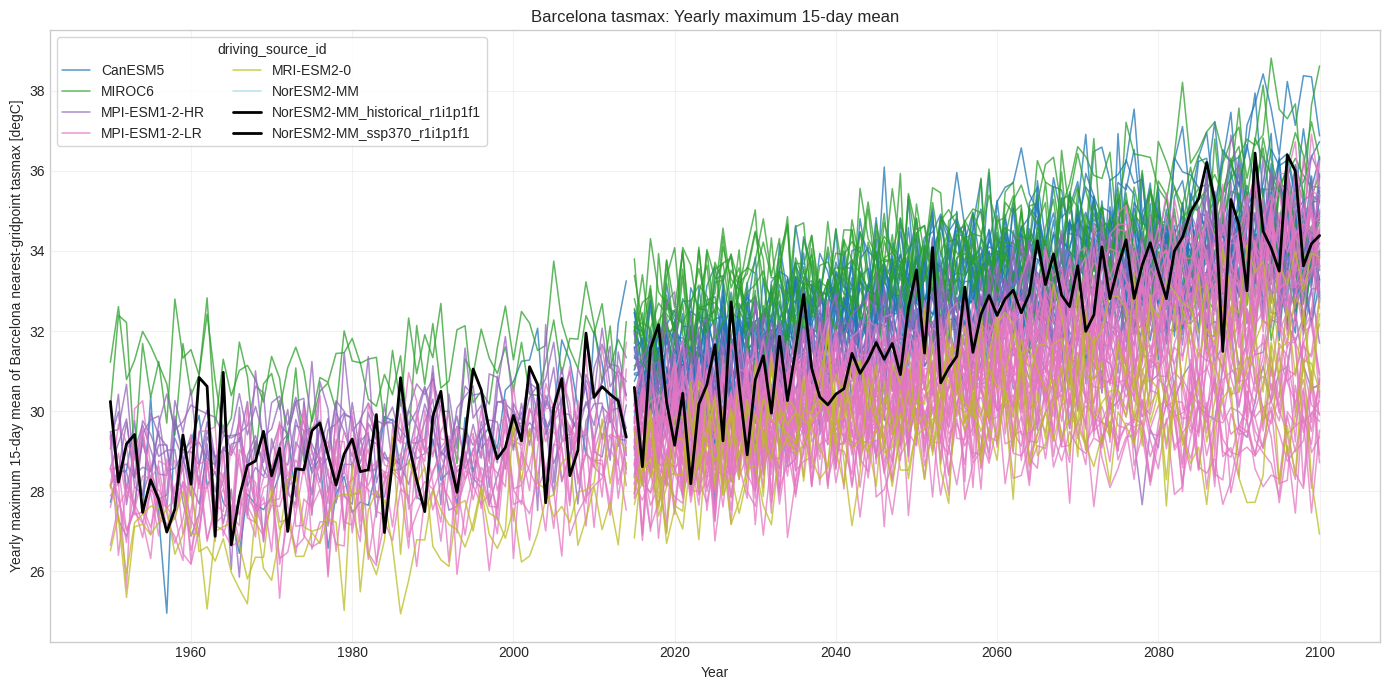

driving_source_id  experiment_id  scenario_group
CanESM5            historical     historical         1
                   ssp245         ssp               20
                   ssp370         ssp                1
                   ssp434         ssp                1
                   ssp460         ssp                2
MIROC6             historical     historical         2
                   ssp126         ssp                3
                   ssp245         ssp                2
                   ssp370         ssp                3
                   ssp434         ssp                1
                   ssp460         ssp                1
                   ssp585         ssp                1
MPI-ESM1-2-HR      historical     historical         8
                   ssp126         ssp                1
                   ssp245         ssp                2
                   ssp370         ssp                9
                   ssp585         ssp                1
MPI-ESM1-2-LR   

In [6]:
metric_name = next(iter(metric_cache.data_vars))
summary = pd.DataFrame(
    {
        "member": metric_cache.member.values,
        "driving_source_id": metric_cache.driving_source_id.values,
        "experiment_id": metric_cache.experiment_id.values,
        "scenario_group": metric_cache.scenario_group.values,
        "variant_label": metric_cache.variant_label.values,
        "source_id": metric_cache.source_id.values,
        "time_range": metric_cache.time_range.values,
    }
)

metric = metric_cache[metric_name]
driving_source_colors = build_driving_source_colors(metric)

fig, ax = plt.subplots(figsize=(14, 7))
plot_member_ensemble(ax, metric, colors=driving_source_colors)
plot_highlight_member(ax, metric, HIGHLIGHT_MEMBERS)
format_time_series_axes(
    ax,
    f"{CITY} {VARIABLE}: {metric.title}",
    f"{metric.attrs.get('long_name', metric_name)} [{metric.attrs.get('units', '')}]"
)
save_figure(fig, f"01_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_members", config)
plt.show()

summary.groupby(["driving_source_id", "experiment_id", "scenario_group"]).size().rename("n_files")

## 4. Convert To Anomalies Relative To A Historical Baseline

Here the member series are recentered relative to the mean for a given period (`REFERENCE_PERIOD`) of each driving model, using only the historical experiment. This makes it easier to compare long-term departures from each model's own baseline rather than comparing absolute metric values directly.

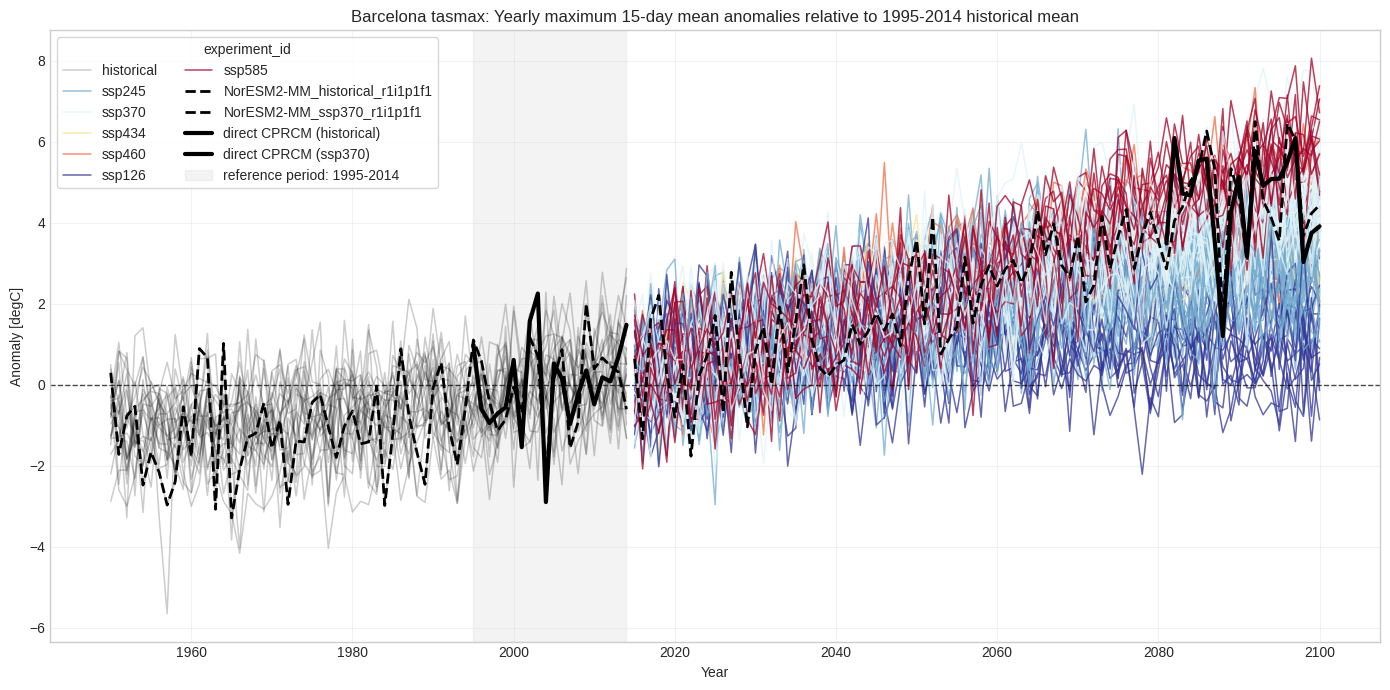

,emulator_reference,cprcm_reference
driving_source_id,,
CanESM5,30.604084,NaN
MIROC6,31.558237,NaN
MPI-ESM1-2-HR,29.871180,NaN
MPI-ESM1-2-LR,28.846512,NaN
MRI-ESM2-0,27.789196,NaN
NorESM2-MM,29.943542,31.424427


In [7]:
historical_reference = compute_historical_reference(metric, summary, REFERENCE_PERIOD)

anomaly_metric = compute_anomaly_metric(metric, historical_reference, metric_name, REFERENCE_PERIOD)
ssp_colors = build_experiment_colors(anomaly_metric)

cprcm_files = sorted(
    path
    for path in CPRCM_DATA_DIR.glob(f"{VARIABLE}_*.nc")
    if CPRCM_FILENAME_PATTERN.match(path.stem) is not None
)
cprcm_cache = load_or_build_dataset(
    CPRCM_CACHE_PATH,
    lambda: build_cprcm_metric_cache(cprcm_files, config),
    force_recompute=FORCE_RECOMPUTE,
)
cprcm_metric_name = next(iter(cprcm_cache.data_vars))
cprcm_metric = cprcm_cache[cprcm_metric_name]
cprcm_summary = pd.DataFrame(
    {
        "member": cprcm_cache.member.values,
        "driving_source_id": cprcm_cache.driving_source_id.values,
        "experiment_id": cprcm_cache.experiment_id.values,
    }
)
cprcm_historical_reference = compute_historical_reference(cprcm_metric, cprcm_summary, REFERENCE_PERIOD)
cprcm_anomaly = compute_anomaly_metric(cprcm_metric, cprcm_historical_reference, cprcm_metric_name, REFERENCE_PERIOD)

fig, ax = plt.subplots(figsize=(14, 7))
plot_member_ensemble(
    ax,
    anomaly_metric,
    colors=ssp_colors,
    color_coord="experiment_id",
    legend_title="experiment_id",
    alpha_by_color_value={"historical": 0.2},
)
plot_highlight_member(ax, anomaly_metric, HIGHLIGHT_MEMBERS, linestyle="--")
plot_cprcm_anomaly(ax, cprcm_anomaly, color="black", linewidth=3.0)
format_time_series_axes(
    ax,
    f"{CITY} {VARIABLE}: {cprcm_metric.title} anomalies relative to {REFERENCE_PERIOD.start}-{REFERENCE_PERIOD.stop} historical mean",
    f"Anomaly [{metric.attrs.get('units', '')}]",
    reference_period=REFERENCE_PERIOD,
    show_zero_line=True,
    legend_title="experiment_id",
)
save_figure(fig, f"02_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_anomalies_emulator_cprcm_eobs", config)
plt.show()

pd.DataFrame({
    "emulator_reference": historical_reference,
    "cprcm_reference": cprcm_historical_reference,
})


## 5. Add An Observational Reference

The observational series provides a benchmark close to the selected city. In the active `tasmax` example, a nearest-gridpoint E-OBS daily maximum temperature series is downloaded, reduced to the same yearly diagnostic, and converted to anomalies using the same reference period so it can be plotted against the emulator output.

For a precipitation metric, point `EOBS_URL`, `EOBS_CACHE_PATH`, and the observational loader to a compatible precipitation dataset before rebuilding the observational metric cache.

In [8]:
eobs_metric = load_or_build_eobs_metric(config)
eobs_reference = eobs_metric.sel(year=slice(REFERENCE_PERIOD.start, REFERENCE_PERIOD.stop)).mean()
eobs_anomaly = (eobs_metric - eobs_reference).rename("eobs_anomaly")
eobs_reference.values.item()

29.791133880615234

## 6. Illustrate Ranking-Based Member Selection

This section shows one possible user workflow: WP5 ranking methods are used to identify a limited subset of CMIP6 GCMs and, thus, emulator members, and those members are emphasized for a chosen time prediction window. The ranking machinery in the notebook is independent of the selected metric, provided the ranking member IDs can be matched to the available emulator members.

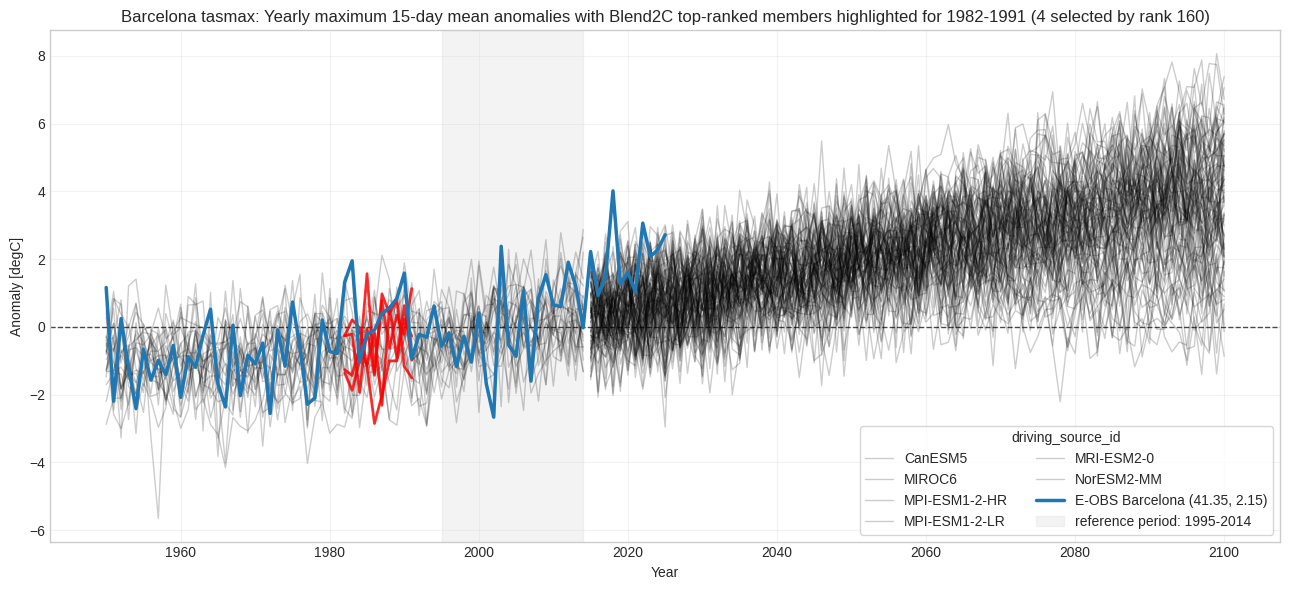

,rank,member,selected
0,1,MIROC6_historical_r24i1p1f1,
1,2,MIROC6_historical_r29i1p1f1,
2,3,MIROC6_historical_r36i1p1f1,
3,4,MIROC6_historical_r23i1p1f1,
4,5,MIROC6_historical_r43i1p1f1,
...,...,...,...
155,156,CNRM-CM6-1_historical_r7i1p1f2,
156,157,CNRM-CM6-1_historical_r21i1p1f2,
157,158,MIROC6_historical_r20i1p1f1,
158,159,EC-Earth3_historical_r3i1p1f1,


In [9]:
RANKING_REPOSITORY = "T52-Blending-information"
RANKING_METHOD_SPECS = {
    "NAO-Teleconnect": {
        "file_template": "{start_year}_pyrs20DJF_NAO_ObsTHoldPnt3_ERA5pslERA5tas_PatCor_NM250.csv",
        "layout": "long",
    },
    "BSC-DPPB_PatCor_tos_NAtl_1-3": {
        "file_template": "BSC-DPPB_PatCor_tos_s{start_year}_NAtl_cFYrs1-3_centered.csv",
        "layout": "long",
    },
    "Blend2C": {
        "file_template": "Blend2C_ranked_members_SubsetOBS_TAS_MED_JJA.csv",
        "layout": "wide",
    },
}

RANKING_HIGHLIGHT_START_YEAR = RANKING_START_YEAR + 1
RANKING_HIGHLIGHT_YEARS = 10
RANKING_HIGHLIGHT_COUNT = 10

ranking, ranking_members = load_ranking_members(
    RANKING_METHOD,
    RANKING_METHOD_SPECS,
    RANKING_REPOSITORY,
    RANKING_START_YEAR,
)

available_members = {str(member) for member in anomaly_metric.member.values}
ranked_members, selected_rows = select_ranked_members(
    ranking_members,
    available_members,
    RANKING_HIGHLIGHT_COUNT,
)

highlight_window_end = RANKING_HIGHLIGHT_START_YEAR + RANKING_HIGHLIGHT_YEARS - 1
rank_cutoff = len(selected_rows)
selection_summary = f"({len(ranked_members)} selected by rank {rank_cutoff})"

fig, ax = plt.subplots(figsize=(13, 6))
plot_member_ensemble(ax, anomaly_metric, alpha=0.2, linewidth=1.0, line_color="black")

for member in ranked_members:
    member_series = anomaly_metric.sel(member=member)
    segment = member_series.sel(year=slice(RANKING_HIGHLIGHT_START_YEAR, highlight_window_end))
    ax.plot(
        segment.year.values,
        segment.values,
        color="red",
        alpha=0.8,
        linewidth=2.0,
        zorder=4,
    )

ax.plot(
    eobs_anomaly.year.values,
    eobs_anomaly.values,
    color="#1f77b4",
    linewidth=2.5,
    label=f"E-OBS {eobs_metric.attrs['location_name']} ({eobs_metric.attrs['selected_lat']:.2f}, {eobs_metric.attrs['selected_lon']:.2f})",
    zorder=5,
)

format_time_series_axes(
    ax,
    f"{CITY} {VARIABLE}: {metric.title} anomalies with {RANKING_METHOD} top-ranked members highlighted for {RANKING_HIGHLIGHT_START_YEAR}-{highlight_window_end} {selection_summary}",
    f"Anomaly [{metric.attrs.get('units', '')}]",
    reference_period=REFERENCE_PERIOD,
    show_zero_line=True,
)
save_figure(fig, f"03_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{RANKING_METHOD}_{RANKING_START_YEAR}_ranked_members", config)
plt.show()

ranking_preview = ranking.iloc[: len(selected_rows)].copy()
ranking_preview.insert(0, "rank", range(1, len(ranking_preview) + 1))
ranking_preview["selected"] = ["yes" if value else "" for value in selected_rows]
ranking_preview

## 7. Compare Full-Ensemble And Ranked-Subset Spread Across Start Years

This section compares how wide the emulator spread is for the full ensemble versus the top-ranked subset for each available start year of a chosen ranking method. The comparison is summarized over the corresponding highlight window and is designed to be a useful precursor to later probabilistic skill diagnostics against the observational evolution.

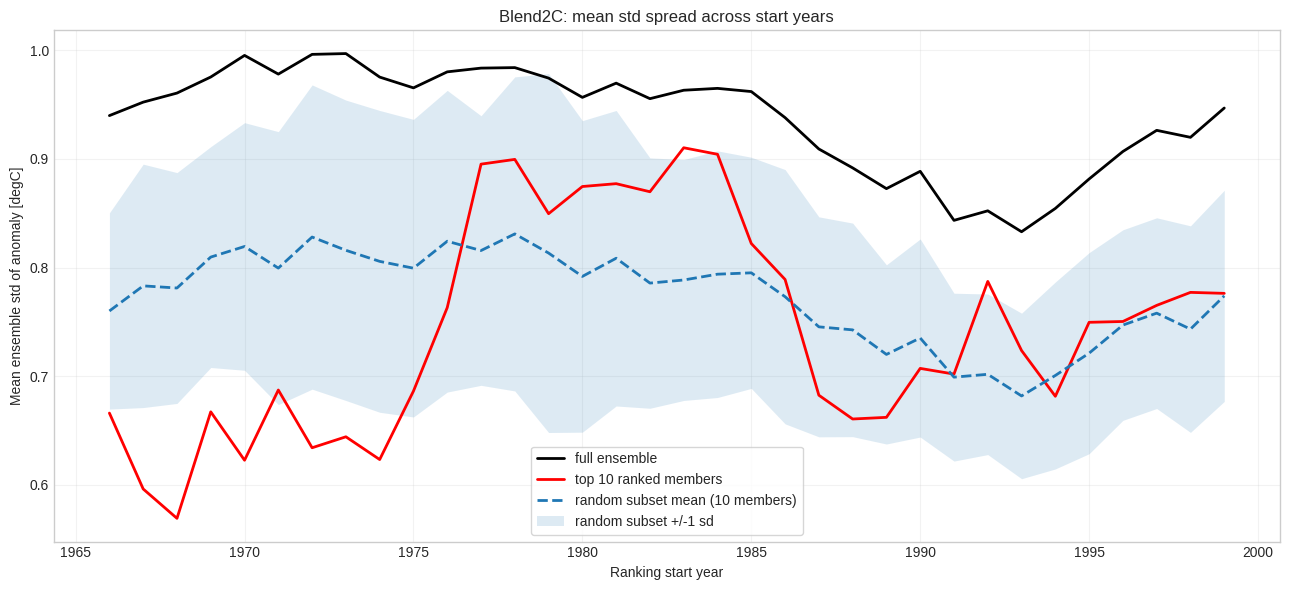

,method,start_year,window_start,window_end,n_ranked_members,rank_cutoff,full_spread,ranked_spread,random_spread,random_spread_std,ranked_minus_random_spread,ranked_to_random_spread_ratio,full_envelope_coverage,ranked_envelope_coverage,random_envelope_coverage,random_coverage_std,ranked_minus_random_coverage
0,Blend2C,1966,1967,1976,4,160,0.939966,0.665979,0.760019,0.090372,-0.094041,0.876265,1.0,0.4,0.6210,0.123023,-0.2210
1,Blend2C,1967,1968,1977,4,160,0.952362,0.596082,0.783142,0.112091,-0.187060,0.761142,1.0,0.4,0.6320,0.115511,-0.2320
2,Blend2C,1968,1969,1978,4,160,0.960714,0.569028,0.781165,0.106309,-0.212137,0.728435,1.0,0.3,0.6450,0.107857,-0.3450
3,Blend2C,1969,1970,1979,4,160,0.975513,0.667126,0.809659,0.101699,-0.142533,0.823959,1.0,0.4,0.6130,0.108118,-0.2130
4,Blend2C,1970,1971,1980,4,160,0.995399,0.622546,0.819421,0.114023,-0.196875,0.759739,1.0,0.3,0.6075,0.127179,-0.3075
5,Blend2C,1971,1972,1981,4,160,0.978179,0.687219,0.799504,0.125697,-0.112286,0.859556,1.0,0.4,0.6180,0.123092,-0.2180
6,Blend2C,1972,1973,1982,4,160,0.996362,0.634043,0.828111,0.140108,-0.194068,0.765649,1.0,0.4,0.6470,0.116442,-0.2470
7,Blend2C,1973,1974,1983,4,160,0.997095,0.644141,0.815901,0.138339,-0.171760,0.789485,0.9,0.3,0.5720,0.117409,-0.2720
8,Blend2C,1974,1975,1984,4,160,0.975443,0.623194,0.805704,0.138981,-0.182510,0.773477,0.9,0.3,0.5790,0.114123,-0.2790
9,Blend2C,1975,1976,1985,4,160,0.965507,0.686226,0.799426,0.137045,-0.113200,0.858399,0.9,0.4,0.6390,0.113328,-0.2390


In [10]:
import numpy as np

SPREAD_METHOD = RANKING_METHOD
SPREAD_SUMMARY_STAT = "std"
SPREAD_HIGHLIGHT_COUNT = RANKING_HIGHLIGHT_COUNT
SPREAD_WINDOW_YEARS = RANKING_HIGHLIGHT_YEARS
SPREAD_RANDOM_SEED = 42
SPREAD_RANDOM_DRAWS = 200
AVAILABLE_START_YEARS = {
    "Blend2C": slice(1966, 2000),
    "NAO-Teleconnect": slice(1971, 2004), #2023),
    "BSC-DPPB_PatCor_tos_NAtl_1-3": slice(2014, 2024),
}

def resolve_start_years(method, start_years):
    method_years = start_years[method] if isinstance(start_years, dict) else start_years
    if isinstance(method_years, slice):
        if method_years.start is None or method_years.stop is None:
            raise ValueError(f"Slice start and stop must be defined for {method}")
        step = 1 if method_years.step is None else method_years.step
        return list(range(method_years.start, method_years.stop, step))
    return [int(start_year) for start_year in method_years]


def summarize_member_spread(metric_slice, statistic="std"):
    if metric_slice.sizes.get("member", 0) < 2:
        return float("nan")

    valid_members = metric_slice.notnull().any(dim="year")
    metric_slice = metric_slice.sel(member=metric_slice.member[valid_members])
    if metric_slice.sizes.get("member", 0) < 2:
        return float("nan")

    if statistic == "std":
        yearly_spread = metric_slice.std(dim="member", skipna=True)
    elif statistic == "range":
        yearly_spread = metric_slice.max(dim="member", skipna=True) - metric_slice.min(dim="member", skipna=True)
    elif statistic == "iqr":
        yearly_spread = metric_slice.quantile(0.75, dim="member") - metric_slice.quantile(0.25, dim="member")
    else:
        raise ValueError(f"Unsupported spread statistic: {statistic}")

    return float(yearly_spread.mean(dim="year", skipna=True).item())


def compute_envelope_coverage(metric_slice, observed_slice):
    overlap_years = observed_slice.year.to_index().intersection(metric_slice.year.to_index())
    if len(overlap_years) == 0 or metric_slice.sizes.get("member", 0) == 0:
        return float("nan")

    observed_window = observed_slice.sel(year=overlap_years)
    metric_window = metric_slice.sel(year=overlap_years)
    valid_members = metric_window.notnull().any(dim="year")
    metric_window = metric_window.sel(member=metric_window.member[valid_members])
    if metric_window.sizes.get("member", 0) == 0:
        return float("nan")

    covered = (
        (observed_window >= metric_window.min(dim="member", skipna=True))
        & (observed_window <= metric_window.max(dim="member", skipna=True))
    )
    return float(covered.mean().item())
def summarize_random_subset_baseline(
    full_slice,
    observed_slice,
    subset_size,
    rng,
    draws=200,
    statistic="std",
):
    valid_mask = full_slice.notnull().any(dim="year")
    eligible_members = [str(member) for member in full_slice.member.values[valid_mask.values]]
    if len(eligible_members) < subset_size or subset_size < 2:
        return {
            "random_spread": float("nan"),
            "random_spread_std": float("nan"),
            "random_envelope_coverage": float("nan"),
            "random_coverage_std": float("nan"),
        }

    spread_samples = []
    coverage_samples = []
    for _ in range(draws):
        sampled_members = rng.choice(eligible_members, size=subset_size, replace=False).tolist()
        sampled_slice = full_slice.sel(member=sampled_members)
        spread_samples.append(summarize_member_spread(sampled_slice, statistic=statistic))
        coverage_samples.append(compute_envelope_coverage(sampled_slice, observed_slice))

    spread_samples = pd.Series(spread_samples, dtype=float)
    coverage_samples = pd.Series(coverage_samples, dtype=float)
    return {
        "random_spread": float(spread_samples.mean(skipna=True)),
        "random_spread_std": float(spread_samples.std(skipna=True)),
        "random_envelope_coverage": float(coverage_samples.mean(skipna=True)),
        "random_coverage_std": float(coverage_samples.std(skipna=True)),
    }


def compute_ranked_subset_spread_table(
    method,
    config,
    anomaly_metric,
    eobs_anomaly,
    ranking_method_specs,
    ranking_repository,
    start_years,
    highlight_count,
    window_years,
    statistic,
    random_seed,
    random_draws,
):
    available_members = [str(member) for member in anomaly_metric.member.values]
    available_member_set = set(available_members)
    available_start_years = resolve_start_years(method, start_years)
    rng = np.random.default_rng(random_seed)

    records = []
    for start_year in available_start_years:
        ranking, ranking_members = load_ranking_members(
            method,
            ranking_method_specs,
            ranking_repository,
            start_year,
        )
        ranked_members, selected_rows = select_ranked_members(
            ranking_members,
            available_member_set,
            highlight_count,
        )
        if not ranked_members:
            continue

        window_start = start_year + 1
        window_end = start_year + window_years
        full_slice = anomaly_metric.sel(year=slice(window_start, window_end))
        ranked_slice = full_slice.sel(member=ranked_members)
        eobs_slice = eobs_anomaly.sel(year=slice(window_start, window_end))

        if full_slice.sizes.get("year", 0) == 0 or ranked_slice.sizes.get("year", 0) == 0:
            continue

        full_spread = summarize_member_spread(full_slice, statistic=statistic)
        ranked_spread = summarize_member_spread(ranked_slice, statistic=statistic)
        full_coverage = compute_envelope_coverage(full_slice, eobs_slice)
        ranked_coverage = compute_envelope_coverage(ranked_slice, eobs_slice)
        random_baseline = summarize_random_subset_baseline(
            full_slice,
            eobs_slice,
            subset_size=len(ranked_members),
            rng=rng,
            draws=random_draws,
            statistic=statistic,
        )

        records.append(
            {
                "method": method,
                "start_year": start_year,
                "window_start": window_start,
                "window_end": window_end,
                "n_ranked_members": len(ranked_members),
                "rank_cutoff": len(selected_rows),
                "full_spread": full_spread,
                "ranked_spread": ranked_spread,
                "random_spread": random_baseline["random_spread"],
                "random_spread_std": random_baseline["random_spread_std"],
                "ranked_minus_random_spread": ranked_spread - random_baseline["random_spread"],
                "ranked_to_random_spread_ratio": ranked_spread / random_baseline["random_spread"] if pd.notna(random_baseline["random_spread"]) and random_baseline["random_spread"] != 0 else float("nan"),
                "full_envelope_coverage": full_coverage,
                "ranked_envelope_coverage": ranked_coverage,
                "random_envelope_coverage": random_baseline["random_envelope_coverage"],
                "random_coverage_std": random_baseline["random_coverage_std"],
                "ranked_minus_random_coverage": ranked_coverage - random_baseline["random_envelope_coverage"],
            }
        )

    if not records:
        raise ValueError(f"No valid spread comparisons were generated for {method}")

    return pd.DataFrame(records).sort_values("start_year").reset_index(drop=True)


spread_comparison = compute_ranked_subset_spread_table(
    SPREAD_METHOD,
    config,
    anomaly_metric,
    eobs_anomaly,
    RANKING_METHOD_SPECS,
    RANKING_REPOSITORY,
    start_years=AVAILABLE_START_YEARS,
    highlight_count=SPREAD_HIGHLIGHT_COUNT,
    window_years=SPREAD_WINDOW_YEARS,
    statistic=SPREAD_SUMMARY_STAT,
    random_seed=SPREAD_RANDOM_SEED,
    random_draws=SPREAD_RANDOM_DRAWS,
)
spread_comparison.to_csv(FIGURE_DIR / f"{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{SPREAD_METHOD}_spread_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(
    spread_comparison["start_year"],
    spread_comparison["full_spread"],
    color="black",
    linewidth=2.0,
    label="full ensemble",
)
ax.plot(
    spread_comparison["start_year"],
    spread_comparison["ranked_spread"],
    color="red",
    linewidth=2.0,
    label=f"top {SPREAD_HIGHLIGHT_COUNT} ranked members",
)
ax.plot(
    spread_comparison["start_year"],
    spread_comparison["random_spread"],
    color="#1f77b4",
    linewidth=2.0,
    linestyle="--",
    label=f"random subset mean ({SPREAD_HIGHLIGHT_COUNT} members)",
)
ax.fill_between(
    spread_comparison["start_year"],
    spread_comparison["random_spread"] - spread_comparison["random_spread_std"],
    spread_comparison["random_spread"] + spread_comparison["random_spread_std"],
    color="#1f77b4",
    alpha=0.15,
    linewidth=0,
    label="random subset +/-1 sd",
)
ax.set_title(
    f"{SPREAD_METHOD}: mean {SPREAD_SUMMARY_STAT} spread across start years"
)
ax.set_xlabel("Ranking start year")
ax.set_ylabel(f"Mean ensemble {SPREAD_SUMMARY_STAT} of anomaly [{metric.attrs.get('units', '')}]")
ax.legend(frameon=True)
ax.grid(True, alpha=0.25)
plt.tight_layout()
save_figure(fig, f"04_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{SPREAD_METHOD}_spread_comparison", config)
plt.show()

spread_comparison

## 8. Quantify Hindcast Skill By Forecast Horizon

This section asks whether the ranked subset gives more skillful decadal forecasts than random subsets of the same size. The verification unit is one forecast start date and one forecast horizon. For each start date, the forecast and the observation are averaged over the horizon first: year 1 is a one-year value, while years 2-5 and years 6-10 are multi-year means. This matches the decadal-prediction target: the score evaluates the predicted horizon mean, not year-to-year variability within the horizon.

For each start date $s$, horizon $h$, and member $m$, the code first computes a horizon-mean forecast anomaly

$$
f_{s,h,m} = \frac{1}{|h|}\sum_{y \in h} x_{s,y,m}
$$

and a matching horizon-mean observed anomaly

$$
o_{s,h} = \frac{1}{|h|}\sum_{y \in h} \text{obs}_y.
$$

The ranked subset, full ensemble, and each random subset are then scored across all available start dates for the same horizon. CRPS is computed for each start-date ensemble distribution and then averaged across start dates:

$$
CRPS = \frac{1}{N_s}\sum_s \left[\frac{1}{M}\sum_m |f_{s,h,m} - o_{s,h}| - \frac{1}{2M^2}\sum_m\sum_n |f_{s,h,m} - f_{s,h,n}|\right].
$$

Lower CRPS is better. It rewards ensemble distributions that are close to the observation while still accounting for ensemble spread. A CRPS of zero would mean a perfect ensemble forecast for every verified start date.

RMSE is computed from the ensemble mean forecast for each start date:

$$
RMSE = \sqrt{\frac{1}{N_s}\sum_s \left(\frac{1}{M}\sum_m f_{s,h,m} - o_{s,h}\right)^2}.
$$

Lower RMSE is better. It only evaluates the deterministic ensemble mean, so it does not reward or penalize the width of the ensemble distribution except through its effect on the mean.

The skill columns compare the ranked subset with two references:

$$
CRPSS_{ranked-vs-full} = 1 - \frac{CRPS_{ranked}}{CRPS_{full}}
$$

and

$$
CRPSS_{ranked-vs-rand} = 1 - \frac{CRPS_{ranked}}{CRPS_{rand}}.
$$

Positive values mean the ranked subset has lower CRPS than the reference; zero means equal CRPS; negative values mean the ranked subset is worse. For example, $0.2$ means a 20% CRPS reduction, while $-0.2$ means a 20% CRPS increase relative to the reference.

For RMSE, the improvement columns are simple differences:

$$
RMSE_{improve} = RMSE_{ref} - RMSE_{ranked}.
$$

Positive values mean the ranked subset has lower RMSE than the reference; zero means equal RMSE; negative values mean worse RMSE. The units are the same as the metric anomaly units.

The random-subset benchmark is estimated by repeated draws. For each draw, the code samples random members for every start date, computes the pooled horizon score, and stores the resulting CRPS and RMSE. The `ranked_beats_random_*_fraction` columns show the fraction of random draws that were worse than the ranked subset. Values near 1 indicate that the ranked subset usually beats random member selection; values near 0.5 suggest little separation from random selection; values near 0 indicate that random subsets usually perform better.

Processing Blend2C start year 1966...
Processing Blend2C start year 1967...


Processing Blend2C start year 1968...
Processing Blend2C start year 1969...
Processing Blend2C start year 1970...
Processing Blend2C start year 1971...
Processing Blend2C start year 1972...
Processing Blend2C start year 1973...
Processing Blend2C start year 1974...
Processing Blend2C start year 1975...
Processing Blend2C start year 1976...
Processing Blend2C start year 1977...
Processing Blend2C start year 1978...
Processing Blend2C start year 1979...
Processing Blend2C start year 1980...
Processing Blend2C start year 1981...
Processing Blend2C start year 1982...
Processing Blend2C start year 1983...
Processing Blend2C start year 1984...
Processing Blend2C start year 1985...
Processing Blend2C start year 1986...
Processing Blend2C start year 1987...
Processing Blend2C start year 1988...
Processing Blend2C start year 1989...
Processing Blend2C start year 1990...
Processing Blend2C start year 1991...
Processing Blend2C start year 1992...
Processing Blend2C start year 1993...
Processing B

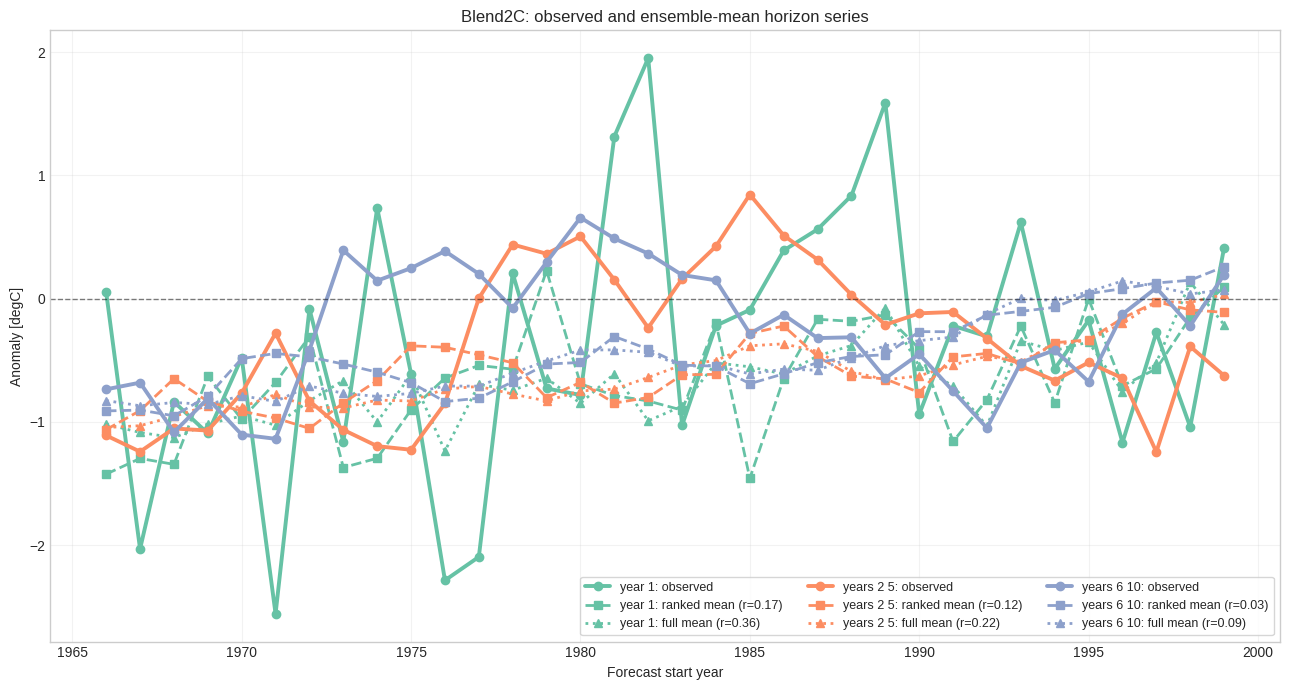

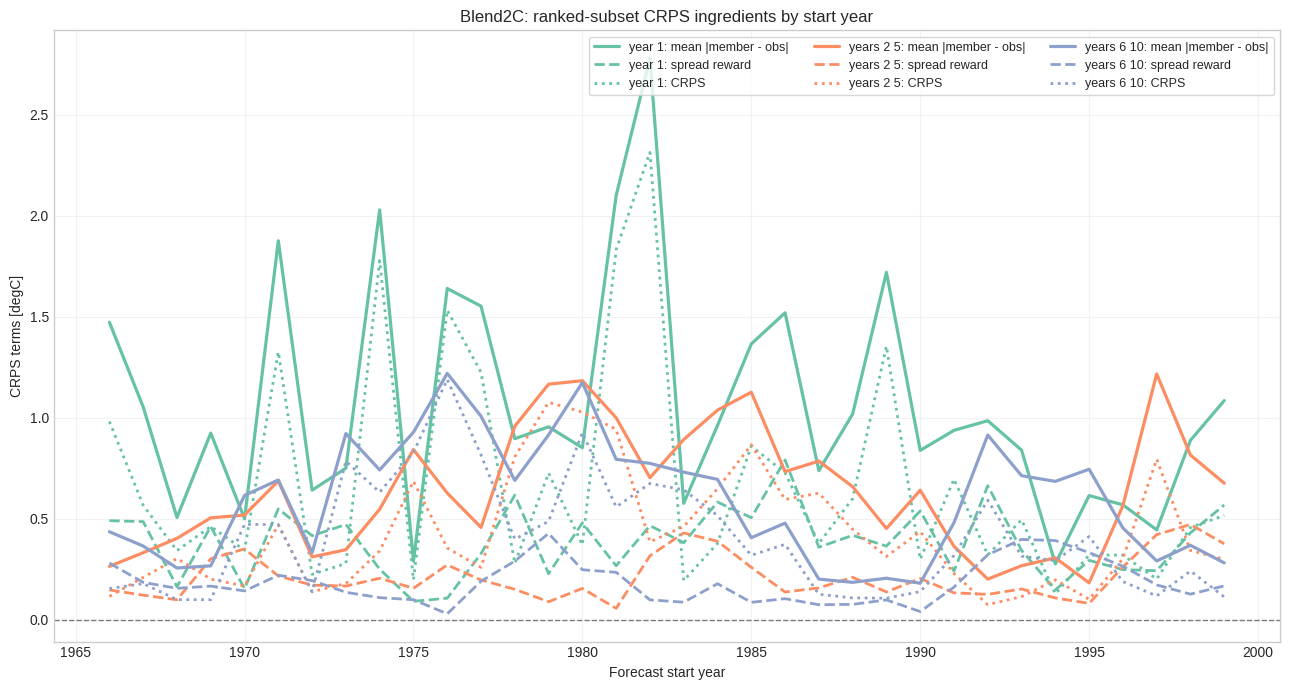

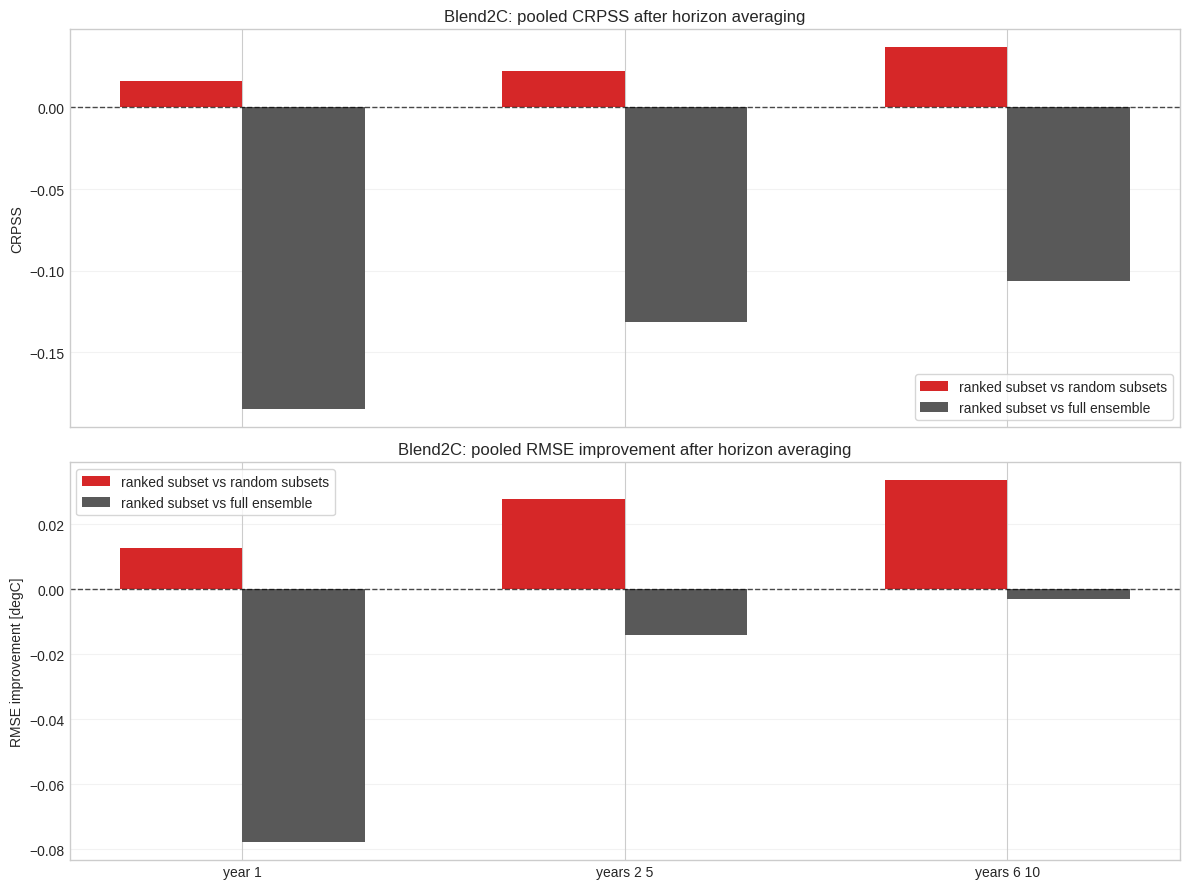

,horizon,method,lead_start,lead_end,n_start_dates,full_crps,ranked_crps,random_crps,random_crps_std,ranked_crpss_vs_full,random_crpss_vs_full,ranked_crpss_vs_random,ranked_beats_random_crps_fraction,full_rmse,ranked_rmse,random_rmse,random_rmse_std,ranked_rmse_improvement_vs_full,random_rmse_improvement_vs_full,ranked_rmse_improvement_vs_random,ranked_beats_random_rmse_fraction
0,year_1,Blend2C,1,1,34,0.572364,0.678035,0.688997,0.052015,-0.184621,-0.203775,0.015911,0.60,1.019805,1.097575,1.110170,0.078138,-0.077770,-0.090365,0.012595,0.535
1,years_2_5,Blend2C,2,5,34,0.378128,0.427768,0.437491,0.029135,-0.131277,-0.156990,0.022224,0.64,0.646626,0.660619,0.688523,0.041943,-0.013993,-0.041897,0.027904,0.745
2,years_6_10,Blend2C,6,10,34,0.368364,0.407564,0.423097,0.028002,-0.106418,-0.148585,0.036712,0.72,0.615171,0.618145,0.651643,0.039887,-0.002974,-0.036472,0.033499,0.795


In [11]:
HINDCAST_METHOD = SPREAD_METHOD
HINDCAST_HIGHLIGHT_COUNT = SPREAD_HIGHLIGHT_COUNT
HINDCAST_WINDOW_YEARS = SPREAD_WINDOW_YEARS
HINDCAST_START_YEARS = AVAILABLE_START_YEARS
HINDCAST_RANDOM_SEED = SPREAD_RANDOM_SEED
HINDCAST_RANDOM_DRAWS = SPREAD_RANDOM_DRAWS
HINDCAST_HORIZON_BINS = {
    "year_1": (1, 1),
    "years_2_5": (2, 5),
    "years_6_10": (6, 10),
}


def crps_ensemble(observation, ensemble_values):
    ensemble = np.asarray(ensemble_values, dtype=float)
    ensemble = ensemble[np.isfinite(ensemble)]
    if ensemble.size == 0 or not np.isfinite(observation):
        return float("nan")

    observation_term = np.mean(np.abs(ensemble - observation))
    pairwise_term = 0.5 * np.mean(np.abs(ensemble[:, None] - ensemble[None, :]))
    return float(observation_term - pairwise_term)


def crps_ensemble_terms(observation, ensemble_values):
    ensemble = np.asarray(ensemble_values, dtype=float)
    ensemble = ensemble[np.isfinite(ensemble)]
    if ensemble.size == 0 or not np.isfinite(observation):
        return {"distance_term": float("nan"), "spread_term": float("nan"), "crps": float("nan")}

    distance_term = float(np.mean(np.abs(ensemble - observation)))
    spread_term = float(0.5 * np.mean(np.abs(ensemble[:, None] - ensemble[None, :])))
    return {
        "distance_term": distance_term,
        "spread_term": spread_term,
        "crps": distance_term - spread_term,
    }


def rmse_ensemble_mean(observed_values, forecast_values):
    observed = np.asarray(observed_values, dtype=float)
    forecast = np.asarray(forecast_values, dtype=float)
    valid = np.isfinite(observed) & np.isfinite(forecast)
    if not np.any(valid):
        return float("nan")
    return float(np.sqrt(np.mean((forecast[valid] - observed[valid]) ** 2)))
def build_horizon_mean_case(metric_slice, observed_slice, years):
    if not years:
        return None

    metric_years = metric_slice.sel(year=years)
    observed_years = observed_slice.sel(year=years)
    if metric_years.sizes.get("year", 0) == 0 or observed_years.sizes.get("year", 0) == 0:
        return None

    member_means = metric_years.mean(dim="year", skipna=True)
    valid_members = member_means.notnull()
    ensemble_values = np.asarray(member_means.values[valid_members.values], dtype=float)
    observation = float(observed_years.mean(dim="year", skipna=True).item())
    if ensemble_values.size == 0 or not np.isfinite(observation):
        return None

    return {
        "observation": observation,
        "ensemble_values": ensemble_values,
        "ensemble_mean": float(np.mean(ensemble_values)),
        "n_members": int(ensemble_values.size),
        "n_years": len(years),
    }


def evaluate_horizon_mean_cases(cases):
    valid_cases = [case for case in cases if case is not None]
    if not valid_cases:
        return {"crps": float("nan"), "rmse": float("nan"), "n_cases": 0}

    crps_values = [crps_ensemble(case["observation"], case["ensemble_values"]) for case in valid_cases]
    observations = [case["observation"] for case in valid_cases]
    ensemble_means = [case["ensemble_mean"] for case in valid_cases]
    return {
        "crps": float(pd.Series(crps_values, dtype=float).mean(skipna=True)),
        "rmse": rmse_ensemble_mean(observations, ensemble_means),
        "n_cases": len(valid_cases),
    }


def sample_random_horizon_case(full_slice, observed_slice, years, subset_size, rng):
    full_case = build_horizon_mean_case(full_slice, observed_slice, years)
    if full_case is None or full_case["n_members"] < subset_size or subset_size < 2:
        return None

    metric_years = full_slice.sel(year=years)
    member_means = metric_years.mean(dim="year", skipna=True)
    valid_members = member_means.member.values[member_means.notnull().values]
    sampled_members = rng.choice(valid_members, size=subset_size, replace=False).tolist()
    sampled_slice = full_slice.sel(member=sampled_members)
    return build_horizon_mean_case(sampled_slice, observed_slice, years)


def summarize_random_strategy(case_specs, rng, draws=200):
    if not case_specs:
        return {
            "crps": float("nan"),
            "crps_std": float("nan"),
            "rmse": float("nan"),
            "rmse_std": float("nan"),
            "crps_samples": pd.Series(dtype=float),
            "rmse_samples": pd.Series(dtype=float),
        }

    crps_samples = []
    rmse_samples = []
    for _ in range(draws):
        sampled_cases = [
            sample_random_horizon_case(
                spec["full_slice"],
                spec["observed_slice"],
                spec["years"],
                spec["subset_size"],
                rng,
            )
            for spec in case_specs
        ]
        sampled_skill = evaluate_horizon_mean_cases(sampled_cases)
        crps_samples.append(sampled_skill["crps"])
        rmse_samples.append(sampled_skill["rmse"])

    crps_samples = pd.Series(crps_samples, dtype=float)
    rmse_samples = pd.Series(rmse_samples, dtype=float)
    return {
        "crps": float(crps_samples.mean(skipna=True)),
        "crps_std": float(crps_samples.std(skipna=True)),
        "rmse": float(rmse_samples.mean(skipna=True)),
        "rmse_std": float(rmse_samples.std(skipna=True)),
        "crps_samples": crps_samples,
        "rmse_samples": rmse_samples,
    }


def compute_hindcast_skill_table(
    method,
    config,
    anomaly_metric,
    eobs_anomaly,
    ranking_method_specs,
    ranking_repository,
    start_years,
    highlight_count,
    window_years,
    horizon_bins,
    random_seed,
    random_draws,
):
    available_members = [str(member) for member in anomaly_metric.member.values]
    available_member_set = set(available_members)
    available_start_years = resolve_start_years(method, start_years)
    rng = np.random.default_rng(random_seed)

    horizon_cases = {
        horizon_name: {"full": [], "ranked": [], "random_specs": []}
        for horizon_name in horizon_bins
    }

    for start_year in available_start_years:
        print(f"Processing {method} start year {start_year}...")
        ranking, ranking_members = load_ranking_members(
            method,
            ranking_method_specs,
            ranking_repository,
            start_year,
        )
        ranked_members, selected_rows = select_ranked_members(
            ranking_members,
            available_member_set,
            highlight_count,
        )
        if not ranked_members:
            continue

        window_start = start_year + 1
        window_end = start_year + window_years
        full_slice = anomaly_metric.sel(year=slice(window_start, window_end))
        ranked_slice = full_slice.sel(member=ranked_members)
        observed_slice = eobs_anomaly.sel(year=slice(window_start, window_end))

        if full_slice.sizes.get("year", 0) == 0 or ranked_slice.sizes.get("year", 0) == 0:
            continue

        overlap_years = sorted(
            set(int(year) for year in full_slice.year.values).intersection(
                int(year) for year in observed_slice.year.values
            )
        )
        if not overlap_years:
            continue

        for horizon_name, lead_bounds in horizon_bins.items():
            lead_start, lead_end = lead_bounds
            horizon_years = [
                year
                for year in range(start_year + lead_start, start_year + lead_end + 1)
                if year in overlap_years
            ]
            if not horizon_years:
                continue

            full_case = build_horizon_mean_case(full_slice, observed_slice, horizon_years)
            ranked_case = build_horizon_mean_case(ranked_slice, observed_slice, horizon_years)
            if full_case is None or ranked_case is None:
                continue

            full_case.update({"start_year": start_year, "years": horizon_years})
            ranked_case.update({"start_year": start_year, "years": horizon_years})
            horizon_cases[horizon_name]["full"].append(full_case)
            horizon_cases[horizon_name]["ranked"].append(ranked_case)
            horizon_cases[horizon_name]["random_specs"].append(
                {
                    "full_slice": full_slice,
                    "observed_slice": observed_slice,
                    "years": horizon_years,
                    "subset_size": len(ranked_members),
                    "start_year": start_year,
                    "rank_cutoff": len(selected_rows),
                }
            )

    records = []
    series_records = []
    for horizon_name, lead_bounds in horizon_bins.items():
        full_skill = evaluate_horizon_mean_cases(horizon_cases[horizon_name]["full"])
        ranked_skill = evaluate_horizon_mean_cases(horizon_cases[horizon_name]["ranked"])
        random_skill = summarize_random_strategy(
            horizon_cases[horizon_name]["random_specs"],
            rng,
            draws=random_draws,
        )

        if full_skill["n_cases"] == 0 or ranked_skill["n_cases"] == 0:
            continue

        for full_case, ranked_case in zip(
            horizon_cases[horizon_name]["full"],
            horizon_cases[horizon_name]["ranked"],
        ):
            full_crps_terms = crps_ensemble_terms(full_case["observation"], full_case["ensemble_values"])
            ranked_crps_terms = crps_ensemble_terms(ranked_case["observation"], ranked_case["ensemble_values"])
            series_records.append(
                {
                    "method": method,
                    "horizon": horizon_name,
                    "start_year": ranked_case["start_year"],
                    "valid_years": ", ".join(str(year) for year in ranked_case["years"]),
                    "observed": ranked_case["observation"],
                    "ranked_ensemble_mean": ranked_case["ensemble_mean"],
                    "full_ensemble_mean": full_case["ensemble_mean"],
                    "ranked_crps_distance_term": ranked_crps_terms["distance_term"],
                    "ranked_crps_spread_term": ranked_crps_terms["spread_term"],
                    "ranked_crps": ranked_crps_terms["crps"],
                    "full_crps_distance_term": full_crps_terms["distance_term"],
                    "full_crps_spread_term": full_crps_terms["spread_term"],
                    "full_crps": full_crps_terms["crps"],
                }
            )

        records.append(
            {
                "method": method,
                "horizon": horizon_name,
                "lead_start": lead_bounds[0],
                "lead_end": lead_bounds[1],
                "n_start_dates": ranked_skill["n_cases"],
                "full_crps": full_skill["crps"],
                "ranked_crps": ranked_skill["crps"],
                "random_crps": random_skill["crps"],
                "random_crps_std": random_skill["crps_std"],
                "ranked_crpss_vs_full": 1 - ranked_skill["crps"] / full_skill["crps"] if pd.notna(full_skill["crps"]) and full_skill["crps"] != 0 else float("nan"),
                "random_crpss_vs_full": 1 - random_skill["crps"] / full_skill["crps"] if pd.notna(full_skill["crps"]) and full_skill["crps"] != 0 else float("nan"),
                "ranked_crpss_vs_random": 1 - ranked_skill["crps"] / random_skill["crps"] if pd.notna(random_skill["crps"]) and random_skill["crps"] != 0 else float("nan"),
                "ranked_beats_random_crps_fraction": float((random_skill["crps_samples"] > ranked_skill["crps"]).mean()) if not random_skill["crps_samples"].empty else float("nan"),
                "full_rmse": full_skill["rmse"],
                "ranked_rmse": ranked_skill["rmse"],
                "random_rmse": random_skill["rmse"],
                "random_rmse_std": random_skill["rmse_std"],
                "ranked_rmse_improvement_vs_full": full_skill["rmse"] - ranked_skill["rmse"] if pd.notna(full_skill["rmse"]) and pd.notna(ranked_skill["rmse"]) else float("nan"),
                "random_rmse_improvement_vs_full": full_skill["rmse"] - random_skill["rmse"] if pd.notna(full_skill["rmse"]) and pd.notna(random_skill["rmse"]) else float("nan"),
                "ranked_rmse_improvement_vs_random": random_skill["rmse"] - ranked_skill["rmse"] if pd.notna(random_skill["rmse"]) and pd.notna(ranked_skill["rmse"]) else float("nan"),
                "ranked_beats_random_rmse_fraction": float((random_skill["rmse_samples"] > ranked_skill["rmse"]).mean()) if not random_skill["rmse_samples"].empty else float("nan"),
            }
        )

    if not records:
        raise ValueError(f"No valid hindcast skill comparisons were generated for {method}")

    summary = pd.DataFrame(records).set_index("horizon").reindex(horizon_bins).reset_index()
    series = pd.DataFrame(series_records).sort_values(["horizon", "start_year"]).reset_index(drop=True)
    return summary, series


hindcast_skill_summary, hindcast_skill_series = compute_hindcast_skill_table(
    HINDCAST_METHOD,
    config,
    anomaly_metric,
    eobs_anomaly,
    RANKING_METHOD_SPECS,
    RANKING_REPOSITORY,
    HINDCAST_START_YEARS,
    HINDCAST_HIGHLIGHT_COUNT,
    HINDCAST_WINDOW_YEARS,
    HINDCAST_HORIZON_BINS,
    HINDCAST_RANDOM_SEED,
    HINDCAST_RANDOM_DRAWS,
)
hindcast_skill_summary.to_csv(FIGURE_DIR / f"{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{HINDCAST_METHOD}_hindcast_skill_summary.csv", index=False)
hindcast_skill_series.to_csv(FIGURE_DIR / f"{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{HINDCAST_METHOD}_hindcast_skill_series.csv", index=False)

horizon_colors = dict(zip(HINDCAST_HORIZON_BINS, plt.cm.Set2.colors[: len(HINDCAST_HORIZON_BINS)]))

fig, ax = plt.subplots(figsize=(13, 7))

for horizon_name in HINDCAST_HORIZON_BINS:
    horizon_series = hindcast_skill_series.query("horizon == @horizon_name")
    color = horizon_colors[horizon_name]
    valid_ranked = horizon_series[["observed", "ranked_ensemble_mean"]].notnull().all(axis=1)
    valid_full = horizon_series[["observed", "full_ensemble_mean"]].notnull().all(axis=1)
    ranked_corr = horizon_series.loc[valid_ranked, "observed"].corr(horizon_series.loc[valid_ranked, "ranked_ensemble_mean"])
    full_corr = horizon_series.loc[valid_full, "observed"].corr(horizon_series.loc[valid_full, "full_ensemble_mean"])
    ranked_label = f"r={ranked_corr:.2f}" if pd.notna(ranked_corr) else "r=NA"
    full_label = f"r={full_corr:.2f}" if pd.notna(full_corr) else "r=NA"
    display_horizon = horizon_name.replace("_", " ")

    ax.plot(
        horizon_series["start_year"],
        horizon_series["observed"],
        color=color,
        linewidth=2.8,
        marker="o",
        label=f"{display_horizon}: observed",
    )
    ax.plot(
        horizon_series["start_year"],
        horizon_series["ranked_ensemble_mean"],
        color=color,
        linewidth=2.0,
        linestyle="--",
        marker="s",
        label=f"{display_horizon}: ranked mean ({ranked_label})",
    )
    ax.plot(
        horizon_series["start_year"],
        horizon_series["full_ensemble_mean"],
        color=color,
        linewidth=2.0,
        linestyle=":",
        marker="^",
        label=f"{display_horizon}: full mean ({full_label})",
    )

ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.5)
ax.set_title(f"{HINDCAST_METHOD}: observed and ensemble-mean horizon series")
ax.set_xlabel("Forecast start year")
ax.set_ylabel(f"Anomaly [{metric.attrs.get('units', '')}]")
ax.grid(True, alpha=0.25)
ax.legend(frameon=True, ncol=3, fontsize=9)
plt.tight_layout()
save_figure(fig, f"05_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{HINDCAST_METHOD}_hindcast_horizon_series", config)
plt.show()

fig, ax = plt.subplots(figsize=(13, 7))

for horizon_name in HINDCAST_HORIZON_BINS:
    horizon_series = hindcast_skill_series.query("horizon == @horizon_name")
    color = horizon_colors[horizon_name]
    display_horizon = horizon_name.replace("_", " ")

    ax.plot(
        horizon_series["start_year"],
        horizon_series["ranked_crps_distance_term"],
        color=color,
        linewidth=2.3,
        label=f"{display_horizon}: mean |member - obs|",
    )
    ax.plot(
        horizon_series["start_year"],
        horizon_series["ranked_crps_spread_term"],
        color=color,
        linewidth=2.0,
        linestyle="--",
        label=f"{display_horizon}: spread reward",
    )
    ax.plot(
        horizon_series["start_year"],
        horizon_series["ranked_crps"],
        color=color,
        linewidth=2.0,
        linestyle=":",
        label=f"{display_horizon}: CRPS",
    )

ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.5)
ax.set_title(f"{HINDCAST_METHOD}: ranked-subset CRPS ingredients by start year")
ax.set_xlabel("Forecast start year")
ax.set_ylabel(f"CRPS terms [{metric.attrs.get('units', '')}]")
ax.grid(True, alpha=0.25)
ax.legend(frameon=True, ncol=3, fontsize=9)
plt.tight_layout()
save_figure(fig, f"05_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{HINDCAST_METHOD}_hindcast_crps_ingredients", config)
plt.show()

horizon_labels = hindcast_skill_summary["horizon"].str.replace("_", " ")
x = np.arange(len(hindcast_skill_summary))
bar_width = 0.32

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

axes[0].bar(
    x - bar_width / 2,
    hindcast_skill_summary["ranked_crpss_vs_random"],
    width=bar_width,
    color="tab:red",
    label="ranked subset vs random subsets",
)
axes[0].bar(
    x + bar_width / 2,
    hindcast_skill_summary["ranked_crpss_vs_full"],
    width=bar_width,
    color="0.35",
    label="ranked subset vs full ensemble",
)
axes[0].axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)
axes[0].set_title(f"{HINDCAST_METHOD}: pooled CRPSS after horizon averaging")
axes[0].set_ylabel("CRPSS")
axes[0].legend(frameon=True)
axes[0].grid(True, axis="y", alpha=0.25)

axes[1].bar(
    x - bar_width / 2,
    hindcast_skill_summary["ranked_rmse_improvement_vs_random"],
    width=bar_width,
    color="tab:red",
    label="ranked subset vs random subsets",
)
axes[1].bar(
    x + bar_width / 2,
    hindcast_skill_summary["ranked_rmse_improvement_vs_full"],
    width=bar_width,
    color="0.35",
    label="ranked subset vs full ensemble",
)
axes[1].axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)
axes[1].set_title(f"{HINDCAST_METHOD}: pooled RMSE improvement after horizon averaging")
axes[1].set_ylabel(f"RMSE improvement [{metric.attrs.get('units', '')}]")
axes[1].set_xticks(x)
axes[1].set_xticklabels(horizon_labels)
axes[1].legend(frameon=True)
axes[1].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
save_figure(fig, f"05_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{HINDCAST_METHOD}_hindcast_skill", config)
plt.show()

hindcast_skill_summary
